<a href="https://colab.research.google.com/github/iyadgantengg120-oss/machine-learning/blob/main/ml_p5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

tr = pd.read_csv('/content/train.csv')
te = pd.read_csv('/content/test.csv')
feat = [c for c in tr.columns if c not in ('subject', 'Activity')]

X_train, y_train = tr[feat], tr['Activity']
X_test, y_test = te[feat], te['Activity']
print(f"Dimensi data latih: {X_train.shape[0]} baris, {X_train.shape[1]} kolom")
print(f"Dimensi data uji  : {X_test.shape[0]} baris, {X_test.shape[1]} kolom")
print("Jumlah kelas:", y_train.nunique())

Dimensi data latih: 7352 baris, 561 kolom
Dimensi data uji  : 2947 baris, 561 kolom
Jumlah kelas: 6


In [3]:
classifiers = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42)
}
reducers = {
    'Tanpa Reduksi': None,
    'PCA (95% Info)': PCA(n_components=0.95, random_state=42),
    'LDA (C-1 Fitur)': LDA()   # 6 kelas -> output otomatis = 5 fitur
}

In [4]:
results = []
for clf_name, clf in classifiers.items():
    for red_name, red in reducers.items():
        steps = [('scaler', StandardScaler())]
        if red is not None:
            steps.append(('reducer', red))
        steps.append(('classifier', clf))
        pipe = Pipeline(steps)

        t0 = time.perf_counter(); pipe.fit(X_train, y_train); train_time = time.perf_counter() - t0
        t0 = time.perf_counter(); y_pred = pipe.predict(X_test); infer_time = time.perf_counter() - t0

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        if 'reducer' in pipe.named_steps:
            step_obj = pipe.named_steps['reducer']
            final_dim = step_obj.n_components_ if isinstance(step_obj, PCA) else step_obj.scalings_.shape[1]
        else:
            final_dim = X_train.shape[1]

        results.append({'Model': clf_name, 'Praproses': red_name, 'Jumlah Kolom': final_dim,
                         'Train Time (detik)': round(train_time, 3), 'Inference Time (detik)': round(infer_time, 4),
                         'Akurasi': round(acc, 4), 'F1-Score': round(f1, 4)})

df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False))

| Model     | Praproses       |   Jumlah Kolom |   Train Time (detik) |   Inference Time (detik) |   Akurasi |   F1-Score |
|:----------|:----------------|---------------:|---------------------:|-------------------------:|----------:|-----------:|
| KNN (k=5) | Tanpa Reduksi   |            561 |                0.324 |                   4.7494 |    0.8836 |     0.8827 |
| KNN (k=5) | PCA (95% Info)  |            102 |                1.072 |                   1.0787 |    0.8768 |     0.8762 |
| KNN (k=5) | LDA (C-1 Fitur) |              5 |                2.821 |                   0.1309 |    0.9644 |     0.9643 |
| SVM (RBF) | Tanpa Reduksi   |            561 |                3.283 |                   5.0959 |    0.9518 |     0.9517 |
| SVM (RBF) | PCA (95% Info)  |            102 |                0.961 |                   0.782  |    0.9376 |     0.9374 |
| SVM (RBF) | LDA (C-1 Fitur) |              5 |                1.217 |                   0.1736 |    0.965  |     0.965  |


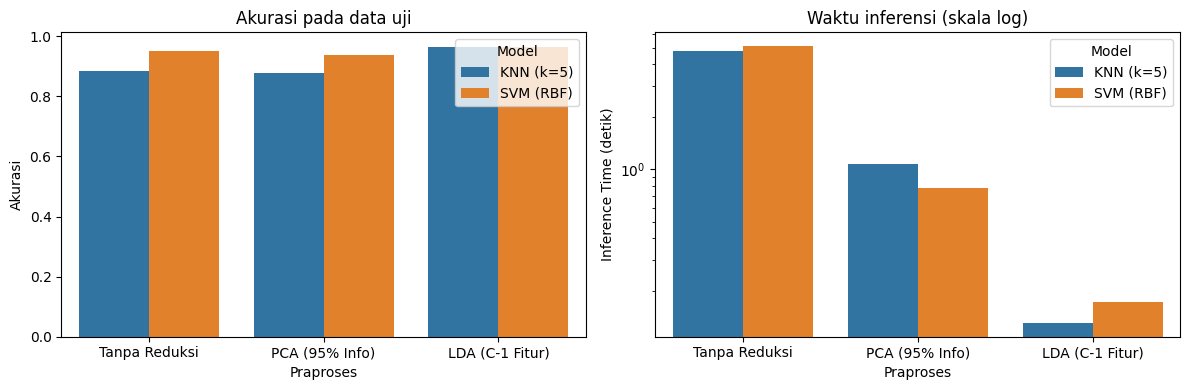

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
order = ['Tanpa Reduksi', 'PCA (95% Info)', 'LDA (C-1 Fitur)']
sns.barplot(data=df_results, x='Praproses', y='Akurasi', hue='Model', order=order, ax=axs[0])
axs[0].set_title('Akurasi pada data uji')
sns.barplot(data=df_results, x='Praproses', y='Inference Time (detik)', hue='Model', order=order, ax=axs[1])
axs[1].set_yscale('log'); axs[1].set_title('Waktu inferensi (skala log)')
plt.tight_layout(); plt.show()

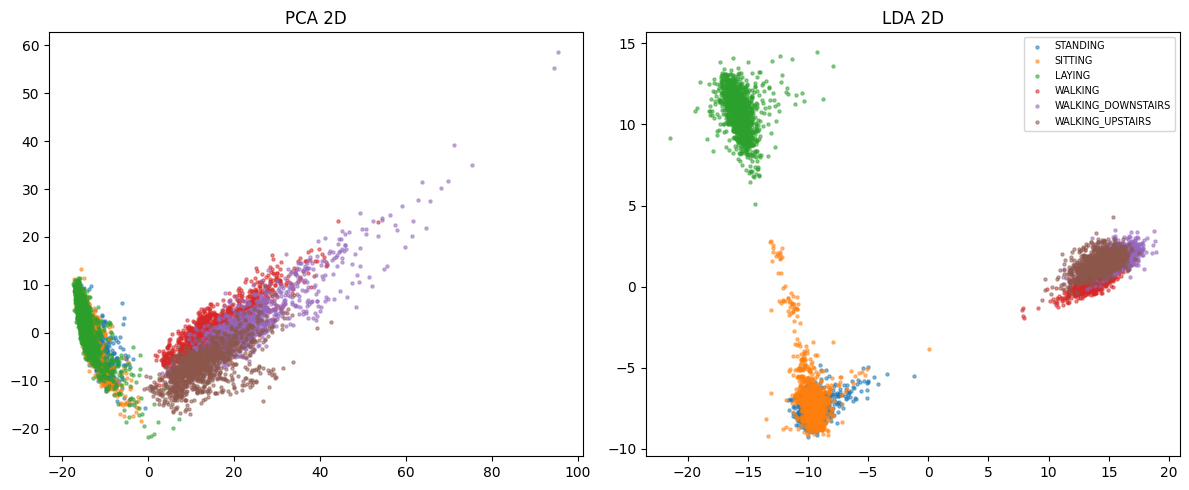

In [6]:
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)

pca_2d = PCA(n_components=2, random_state=42).fit(X_tr_scaled)
X_pca_plot = pca_2d.transform(X_tr_scaled)

lda_2d = LDA(n_components=2).fit(X_tr_scaled, y_train)
X_lda_plot = lda_2d.transform(X_tr_scaled)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for ax, Xp, title in zip(axs, [X_pca_plot, X_lda_plot], ['PCA 2D', 'LDA 2D']):
    for a in y_train.unique():
        m = y_train == a
        ax.scatter(Xp[m, 0], Xp[m, 1], s=5, alpha=0.5, label=a)
    ax.set_title(title)
axs[1].legend(fontsize=7)
plt.tight_layout(); plt.show()